2.1 理论计算题
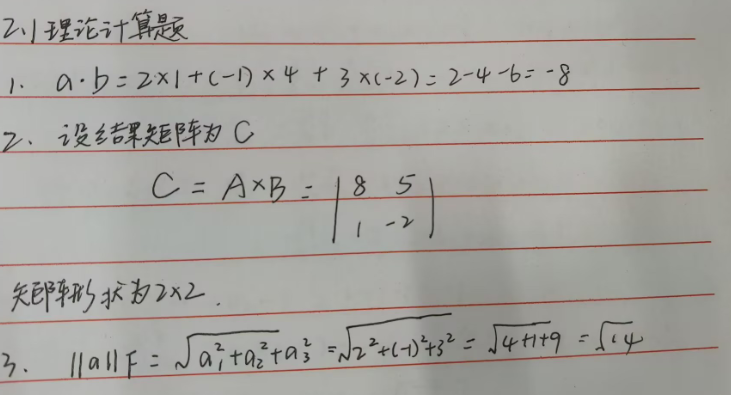

2.2编程题
使用 NumPy（或 MXNet / PyTorch/TensorFlow）完成以下任务：
1. 创建一个形状为 3 × 4 的随机矩阵 X，元素服从标准正态分布。
2. 创建一个形状为 4 × 2 的全 1 矩阵 Y 。
3. 计算矩阵乘法 Z = X × Y 。
4. 输出 Z 的第一行和第二列交叉处的元素，以及 Z 的第 2 行所有元素。
5. 计算 Z 的 Frobenius 范数

In [1]:
import numpy as np

# 设置随机种子，使结果可复现
np.random.seed(42)

# 1. 创建形状为 3×4 的随机矩阵 X，元素服从标准正态分布
X = np.random.randn(3, 4)
print("X =")
print(X)

# 2. 创建形状为 4×2 的全 1 矩阵 Y
Y = np.ones((4, 2))
print("\nY =")
print(Y)

# 3. 计算矩阵乘法 Z = X × Y
Z = np.dot(X, Y)  # 或 X @ Y
print("\nZ = X * Y =")
print(Z)

# 4. 输出 Z 的第一行和第二列交叉处的元素 (索引 [0,1])
element_01 = Z[0, 1]
print(f"\nZ 的第一行第二列交叉处的元素: {element_01}")

# 输出 Z 的第 2 行所有元素 (索引 [1, :])
row_2 = Z[1, :]
print(f"Z 的第二行所有元素: {row_2}")

# 5. 计算 Z 的 Frobenius 范数
fro_norm = np.linalg.norm(Z, 'fro')
print(f"Z 的 Frobenius 范数: {fro_norm:.6f}")

X =
[[ 0.49671415 -0.1382643   0.64768854  1.52302986]
 [-0.23415337 -0.23413696  1.57921282  0.76743473]
 [-0.46947439  0.54256004 -0.46341769 -0.46572975]]

Y =
[[1. 1.]
 [1. 1.]
 [1. 1.]
 [1. 1.]]

Z = X * Y =
[[ 2.52916825  2.52916825]
 [ 1.87835721  1.87835721]
 [-0.85606179 -0.85606179]]

Z 的第一行第二列交叉处的元素: 2.5291682463487657
Z 的第二行所有元素: [1.87835721 1.87835721]
Z 的 Frobenius 范数: 4.616873


3.1 理论计算题
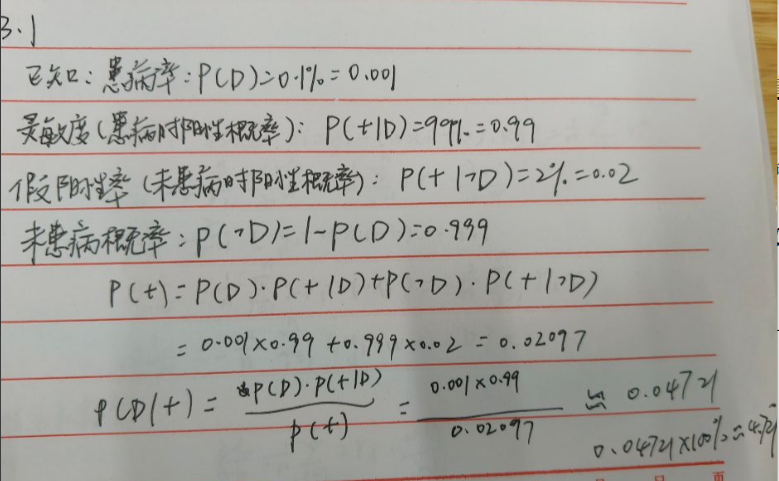

3.2 编程题
用 Python 模拟中心极限定理：
1. 生成 n = 10000 个服从均匀分布 U(0, 1) 的随机变量，重复 m = 1000
次，每次计算这 n 个变量的均值。
2. 绘制这 1000 个均值的直方图，并叠加理论正态分布的概率密度曲线。
3. 计算这些均值的实际方差。

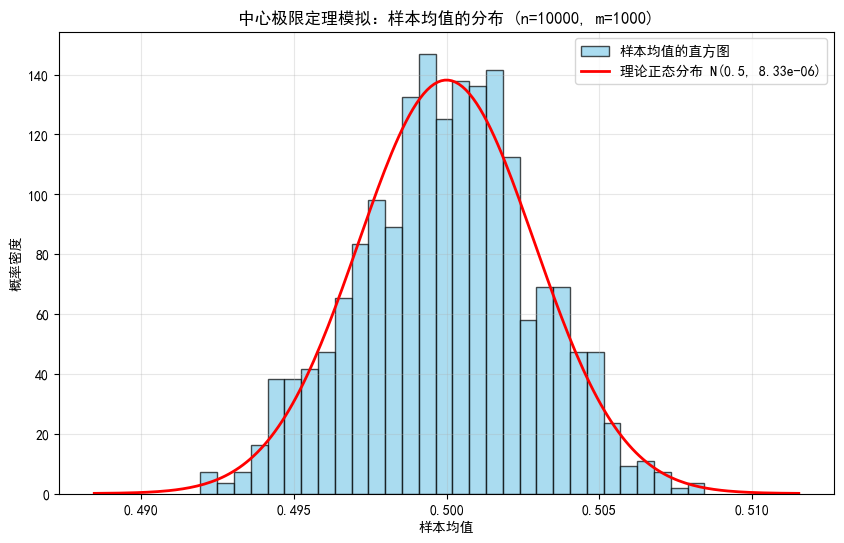

实际方差（样本均值的样本方差）: 8.283921e-06
理论方差 (σ²/n)              : 8.333333e-06
相对误差: 0.59%


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'WenQuanYi Micro Hei']  # 黑体/微软雅黑
plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示为方块的问题
# 参数设置
n = 10000          # 每个样本的容量
m = 1000           # 抽取的样本个数

# 1. 生成 m 个样本均值
# 方法：生成 m 行 n 列的均匀分布随机数，然后按行求均值
np.random.seed(42)  # 保证结果可复现
samples = np.random.uniform(0, 1, size=(m, n))  # 形状 (m, n)
sample_means = np.mean(samples, axis=1)         # 形状 (m,)

# 2. 绘制直方图
plt.figure(figsize=(10, 6))
count, bins, _ = plt.hist(sample_means, bins=30, density=True, 
                          alpha=0.7, color='skyblue', edgecolor='black',
                          label='样本均值的直方图')

# 3. 叠加理论正态分布密度曲线
# 总体 U(0,1) 的均值 μ = 0.5, 方差 σ² = 1/12
# 样本均值的理论分布：N(μ, σ²/n)
mu = 0.5
sigma = np.sqrt(1/12 / n)   # 标准差 = sqrt(方差/n)
x = np.linspace(mu - 4*sigma, mu + 4*sigma, 200)
pdf = norm.pdf(x, mu, sigma)
plt.plot(x, pdf, 'r-', linewidth=2, label=f'理论正态分布 N({mu}, {sigma**2:.2e})')

# 图表修饰
plt.title('中心极限定理模拟：样本均值的分布 (n=10000, m=1000)')
plt.xlabel('样本均值')
plt.ylabel('概率密度')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# 4. 计算实际方差（样本均值的样本方差）
actual_var = np.var(sample_means, ddof=1)   # ddof=1 得到无偏样本方差
theoretical_var = 1/12 / n

print(f"实际方差（样本均值的样本方差）: {actual_var:.6e}")
print(f"理论方差 (σ²/n)              : {theoretical_var:.6e}")
print(f"相对误差: {abs(actual_var - theoretical_var) / theoretical_var * 100:.2f}%")

4.1理论计算题
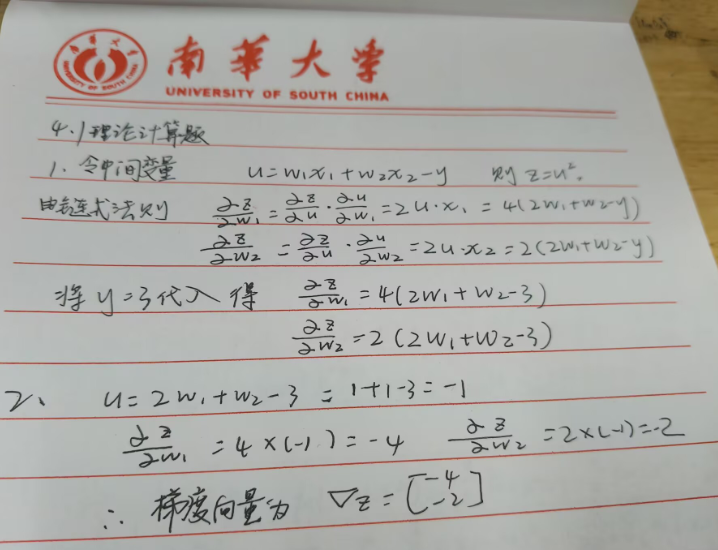

4.2编程题
手动实现一个简单计算图的反向传播：
1. 定义前向计算：输入 x，经过 a = x · w1，b = a + w2，输出 L = b
2。
2. 给定 x = 2, w1 = 1.5, w2 = 0.5，计算前向结果。
3. 手动（按链式法则）计算损失 L 对 w1, w2 的梯度，并验证与自动微分
工具（如 torch.autograd）的结果是否一致。

In [4]:
import torch

# ========== 手动计算前向与反向 ==========
print("===== 手动计算 =====")

# 给定输入
x = 2.0
w1 = 1.5
w2 = 0.5

# 前向传播
a = x * w1
b = a + w2
L = b ** 2

print(f"前向结果: L = {L}")

# 手动链式法则求梯度
# dL/db = 2*b
dL_db = 2 * b
# db/da = 1, da/dw1 = x, db/dw2 = 1
dL_dw1 = dL_db * 1 * x   # 等价于 2*b*x
dL_dw2 = dL_db * 1        # 等价于 2*b

print(f"手动梯度 dL/dw1 = {dL_dw1}")
print(f"手动梯度 dL/dw2 = {dL_dw2}")

# ========== 使用 PyTorch 自动验证 ==========
print("\n===== PyTorch 自动梯度 =====")

# 将变量转为张量并开启梯度追踪
x_t = torch.tensor(x, requires_grad=False)  # x 是输入，不需要梯度
w1_t = torch.tensor(w1, requires_grad=True)
w2_t = torch.tensor(w2, requires_grad=True)

# 前向计算
a_t = x_t * w1_t
b_t = a_t + w2_t
L_t = b_t ** 2

# 反向传播
L_t.backward()

print(f"PyTorch 前向结果: L = {L_t.item()}")
print(f"PyTorch 梯度 dL/dw1 = {w1_t.grad.item()}")
print(f"PyTorch 梯度 dL/dw2 = {w2_t.grad.item()}")

# ========== 结果对比 ==========
print("\n===== 验证一致性 =====")
tol = 1e-6
assert abs(dL_dw1 - w1_t.grad.item()) < tol, "dL/dw1 不一致"
assert abs(dL_dw2 - w2_t.grad.item()) < tol, "dL/dw2 不一致"
print("手动梯度与 PyTorch 自动梯度完全一致，验证通过！")

===== 手动计算 =====
前向结果: L = 12.25
手动梯度 dL/dw1 = 14.0
手动梯度 dL/dw2 = 7.0

===== PyTorch 自动梯度 =====
PyTorch 前向结果: L = 12.25
PyTorch 梯度 dL/dw1 = 14.0
PyTorch 梯度 dL/dw2 = 7.0

===== 验证一致性 =====
手动梯度与 PyTorch 自动梯度完全一致，验证通过！


5.1理论计算题
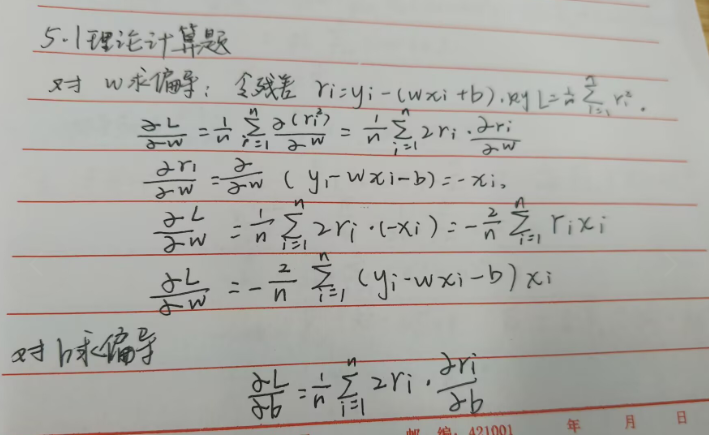
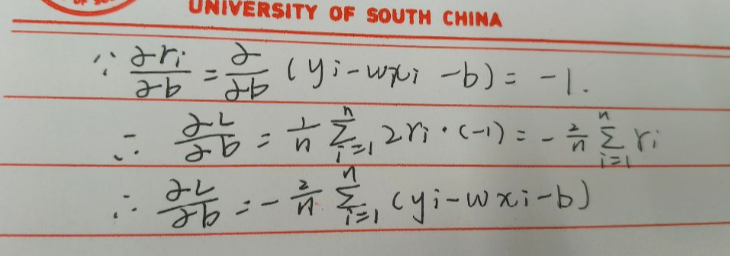

5.2编程题
从零实现 softmax 回归对手写数字（MNIST）进行分类：
1. 使用 sklearn.datasets.load_digits() 或自己加载 MNIST 子集。
2. 将图像展平为向量，对标签进行 one‑hot 编码。
3. 实现 softmax 函数、交叉熵损失函数。
4. 使用小批量随机梯度下降（批量大小 32，学习率 0.1）训练模型 50 个
epoch。
5. 输出测试集上的准确率。

In [5]:
import numpy as np
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 设置随机种子保证可复现
np.random.seed(42)

# 1. 加载数据集并划分训练/测试
digits = load_digits()
X, y = digits.data, digits.target          # X: (1797, 64), y: (1797,)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 特征标准化（可选，但有助于收敛）
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# 2. 对标签进行 one-hot 编码
def one_hot(y, num_classes=10):
    """将整数标签转换为 one-hot 矩阵"""
    m = y.shape[0]
    one_hot = np.zeros((m, num_classes))
    one_hot[np.arange(m), y] = 1
    return one_hot

y_train_onehot = one_hot(y_train)
y_test_onehot = one_hot(y_test)

# 3. 实现 softmax 函数和交叉熵损失
def softmax(logits):
    """输入: (n_samples, n_classes) 输出: 同形状的概率矩阵"""
    exp_logits = np.exp(logits - np.max(logits, axis=1, keepdims=True))  # 数值稳定
    return exp_logits / np.sum(exp_logits, axis=1, keepdims=True)

def cross_entropy_loss(probs, y_onehot):
    """交叉熵损失，取平均"""
    n_samples = probs.shape[0]
    # 避免 log(0) 导致 nan，加极小值
    loss = -np.sum(y_onehot * np.log(probs + 1e-15)) / n_samples
    return loss

# 4. Softmax 回归模型（从零实现）
class SoftmaxRegression:
    def __init__(self, n_features, n_classes, lr=0.1, batch_size=32, epochs=50):
        self.W = np.random.randn(n_features, n_classes) * 0.01
        self.b = np.zeros((1, n_classes))
        self.lr = lr
        self.batch_size = batch_size
        self.epochs = epochs
        self.n_classes = n_classes

    def forward(self, X):
        """前向传播: 返回概率矩阵"""
        logits = X @ self.W + self.b
        return softmax(logits)

    def compute_gradients(self, X_batch, y_batch_onehot):
        """计算一个 batch 的梯度 (W, b)"""
        batch_size = X_batch.shape[0]
        probs = self.forward(X_batch)                     # (batch_size, n_classes)
        # 梯度对 logits: (probs - y_onehot) / batch_size
        dlogits = (probs - y_batch_onehot) / batch_size
        # 梯度对 W: X_batch.T @ dlogits
        dW = X_batch.T @ dlogits
        # 梯度对 b: 对 dlogits 按列求和
        db = np.sum(dlogits, axis=0, keepdims=True)
        return dW, db

    def fit(self, X_train, y_train_onehot, X_val=None, y_val_onehot=None):
        """训练模型，使用小批量 SGD"""
        n_samples = X_train.shape[0]
        # 记录损失
        train_losses = []
        val_losses = []
        val_accs = []

        for epoch in range(self.epochs):
            # 打乱数据
            indices = np.random.permutation(n_samples)
            X_shuffled = X_train[indices]
            y_shuffled = y_train_onehot[indices]

            # 小批量迭代
            for i in range(0, n_samples, self.batch_size):
                X_batch = X_shuffled[i:i+self.batch_size]
                y_batch = y_shuffled[i:i+self.batch_size]

                # 计算梯度
                dW, db = self.compute_gradients(X_batch, y_batch)

                # 更新参数 (SGD)
                self.W -= self.lr * dW
                self.b -= self.lr * db

            # 每个 epoch 结束后计算损失
            train_probs = self.forward(X_train)
            train_loss = cross_entropy_loss(train_probs, y_train_onehot)
            train_losses.append(train_loss)

            if X_val is not None:
                val_probs = self.forward(X_val)
                val_loss = cross_entropy_loss(val_probs, y_val_onehot)
                val_losses.append(val_loss)
                val_acc = self.score(X_val, np.argmax(y_val_onehot, axis=1))
                val_accs.append(val_acc)
                print(f"Epoch {epoch+1}/{self.epochs} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")
            else:
                print(f"Epoch {epoch+1}/{self.epochs} | Train Loss: {train_loss:.4f}")

        return train_losses, val_losses, val_accs

    def predict_proba(self, X):
        """预测概率"""
        return self.forward(X)

    def predict(self, X):
        """预测类别 (0-9)"""
        probs = self.forward(X)
        return np.argmax(probs, axis=1)

    def score(self, X, y_true):
        """计算准确率"""
        y_pred = self.predict(X)
        return np.mean(y_pred == y_true)

# 5. 训练模型
n_features = X_train.shape[1]   # 64
n_classes = len(np.unique(y))   # 10
model = SoftmaxRegression(n_features, n_classes, lr=0.1, batch_size=32, epochs=50)

# 使用训练集训练，同时监控验证集（此处用测试集作为验证，但正常应再分一个验证集）
# 为简单起见，直接用测试集作为验证集（仅用于观察，最终准确率仍用测试集）
print("开始训练...")
train_losses, val_losses, val_accs = model.fit(X_train, y_train_onehot, X_test, y_test_onehot)

# 输出测试集上的最终准确率
test_acc = model.score(X_test, y_test)
print(f"\n测试集准确率: {test_acc:.4f} ({test_acc*100:.2f}%)")

开始训练...
Epoch 1/50 | Train Loss: 0.4655 | Val Loss: 0.4699 | Val Acc: 0.9250
Epoch 2/50 | Train Loss: 0.3091 | Val Loss: 0.3188 | Val Acc: 0.9361
Epoch 3/50 | Train Loss: 0.2458 | Val Loss: 0.2585 | Val Acc: 0.9361
Epoch 4/50 | Train Loss: 0.2100 | Val Loss: 0.2244 | Val Acc: 0.9444
Epoch 5/50 | Train Loss: 0.1862 | Val Loss: 0.2028 | Val Acc: 0.9583
Epoch 6/50 | Train Loss: 0.1688 | Val Loss: 0.1885 | Val Acc: 0.9583
Epoch 7/50 | Train Loss: 0.1554 | Val Loss: 0.1766 | Val Acc: 0.9583
Epoch 8/50 | Train Loss: 0.1448 | Val Loss: 0.1682 | Val Acc: 0.9611
Epoch 9/50 | Train Loss: 0.1358 | Val Loss: 0.1611 | Val Acc: 0.9611
Epoch 10/50 | Train Loss: 0.1282 | Val Loss: 0.1556 | Val Acc: 0.9639
Epoch 11/50 | Train Loss: 0.1217 | Val Loss: 0.1506 | Val Acc: 0.9639
Epoch 12/50 | Train Loss: 0.1161 | Val Loss: 0.1468 | Val Acc: 0.9611
Epoch 13/50 | Train Loss: 0.1111 | Val Loss: 0.1431 | Val Acc: 0.9639
Epoch 14/50 | Train Loss: 0.1066 | Val Loss: 0.1400 | Val Acc: 0.9639
Epoch 15/50 | Train L

6.1理论计算题
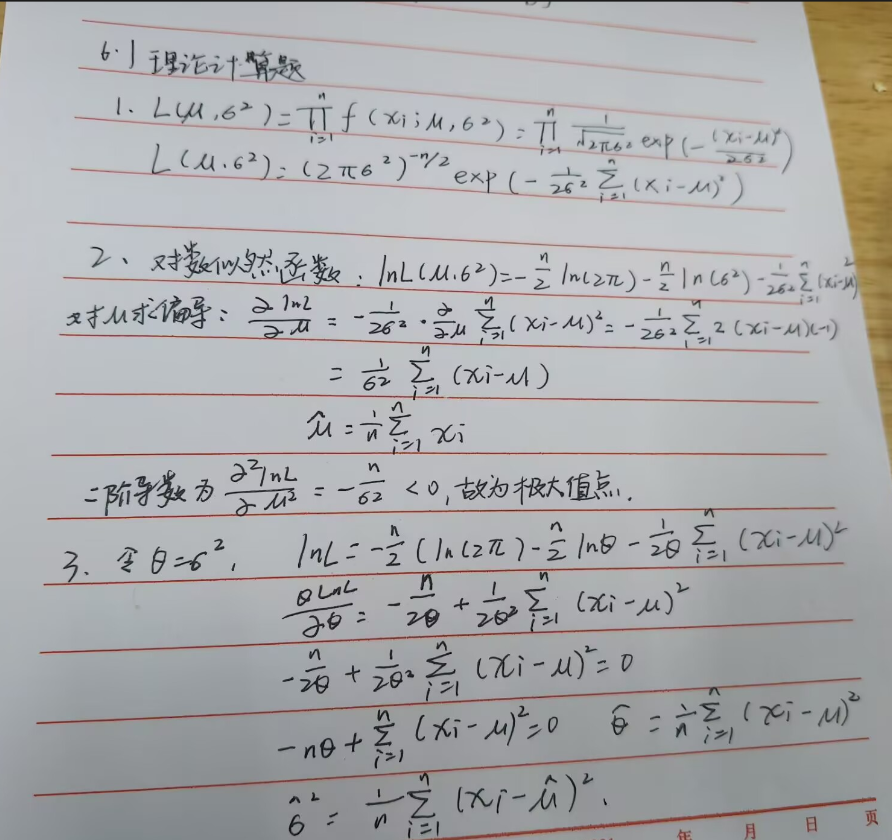

6.2编程题
实现二分类逻辑回归模型（不使用深度学习框架的高阶 API）：
1. 生成两类线性可分的数据：每类 200 个样本，特征维度为 2。
2. 定义 sigmoid 函数和二元交叉熵损失。
3. 使用梯度下降法（学习率 0.1，迭代 1000 次）学习参数 w, b。
4. 绘制决策边界，并计算模型在测试集（新生成 100 个样本）上的分类
准确率。

训练集形状: (200, 2), 标签形状: (200,)
测试集形状: (100, 2), 标签形状: (100,)
开始训练...
Iter    0, loss = 0.693147
Iter  100, loss = 0.379954
Iter  200, loss = 0.298813
Iter  300, loss = 0.258601
Iter  400, loss = 0.234831
Iter  500, loss = 0.219176
Iter  600, loss = 0.208102
Iter  700, loss = 0.199866
Iter  800, loss = 0.193510
Iter  900, loss = 0.188463

训练集准确率: 0.9200 (92.00%)
测试集准确率: 0.9300 (93.00%)


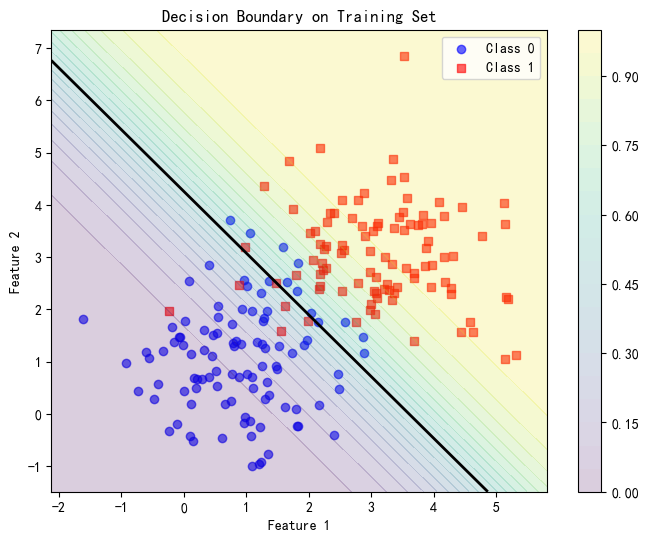

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# 设置随机种子
np.random.seed(42)

# ========== 1. 生成线性可分数据 ==========
def generate_linear_separable_data(n_samples=200, n_features=2):
    """生成两类线性可分数据，每类 n_samples/2 个样本"""
    n_class = n_samples // 2
    # 第一类：均值 (1, 1)，协方差矩阵为单位阵
    X1 = np.random.randn(n_class, n_features) + np.array([1, 1])
    y1 = np.zeros(n_class)
    # 第二类：均值 (3, 3)，协方差矩阵为单位阵
    X2 = np.random.randn(n_class, n_features) + np.array([3, 3])
    y2 = np.ones(n_class)
    X = np.vstack([X1, X2])
    y = np.hstack([y1, y2])
    # 打乱顺序
    idx = np.random.permutation(n_samples)
    return X[idx], y[idx]

# 生成训练集（200样本）和测试集（100样本）
X_train, y_train = generate_linear_separable_data(200)
X_test, y_test = generate_linear_separable_data(100)

print(f"训练集形状: {X_train.shape}, 标签形状: {y_train.shape}")
print(f"测试集形状: {X_test.shape}, 标签形状: {y_test.shape}")

# ========== 2. 定义 sigmoid 和二元交叉熵损失 ==========
def sigmoid(z):
    """sigmoid 函数，数值稳定"""
    z = np.clip(z, -500, 500)  # 防止溢出
    return 1 / (1 + np.exp(-z))

def binary_cross_entropy(y_true, y_pred):
    """二元交叉熵损失，y_pred 是 sigmoid 输出的概率"""
    # 避免 log(0)
    eps = 1e-15
    y_pred = np.clip(y_pred, eps, 1 - eps)
    loss = -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))
    return loss

# ========== 3. 逻辑回归模型（梯度下降） ==========
class LogisticRegressionManual:
    def __init__(self, learning_rate=0.1, n_iter=1000):
        self.lr = learning_rate
        self.n_iter = n_iter
        self.w = None
        self.b = None

    def fit(self, X, y):
        """使用梯度下降训练模型"""
        n_samples, n_features = X.shape
        # 初始化参数
        self.w = np.zeros(n_features)
        self.b = 0.0

        # 记录损失变化
        losses = []

        for i in range(self.n_iter):
            # 线性模型输出
            linear = X @ self.w + self.b
            # 预测概率
            y_pred = sigmoid(linear)

            # 计算梯度
            dw = (1 / n_samples) * X.T @ (y_pred - y)
            db = (1 / n_samples) * np.sum(y_pred - y)

            # 更新参数
            self.w -= self.lr * dw
            self.b -= self.lr * db

            # 记录损失（每 100 次迭代打印一次）
            loss = binary_cross_entropy(y, y_pred)
            losses.append(loss)
            if i % 100 == 0:
                print(f"Iter {i:4d}, loss = {loss:.6f}")

        return losses

    def predict_proba(self, X):
        """预测概率"""
        linear = X @ self.w + self.b
        return sigmoid(linear)

    def predict(self, X, threshold=0.5):
        """预测类别（0 或 1）"""
        proba = self.predict_proba(X)
        return (proba >= threshold).astype(int)

    def score(self, X, y):
        """计算准确率"""
        y_pred = self.predict(X)
        return np.mean(y_pred == y)

# 训练模型
model = LogisticRegressionManual(learning_rate=0.1, n_iter=1000)
print("开始训练...")
losses = model.fit(X_train, y_train)

# 测试集准确率
train_acc = model.score(X_train, y_train)
test_acc = model.score(X_test, y_test)
print(f"\n训练集准确率: {train_acc:.4f} ({train_acc*100:.2f}%)")
print(f"测试集准确率: {test_acc:.4f} ({test_acc*100:.2f}%)")

# ========== 4. 绘制决策边界 ==========
def plot_decision_boundary(X, y, model, title="Decision Boundary"):
    """绘制数据点与决策边界"""
    plt.figure(figsize=(8, 6))
    # 绘制原始数据点
    plt.scatter(X[y==0, 0], X[y==0, 1], c='blue', marker='o', label='Class 0', alpha=0.6)
    plt.scatter(X[y==1, 0], X[y==1, 1], c='red', marker='s', label='Class 1', alpha=0.6)

    # 生成网格点
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                         np.linspace(y_min, y_max, 200))
    grid = np.c_[xx.ravel(), yy.ravel()]
    # 预测网格点概率
    Z = model.predict_proba(grid)
    Z = Z.reshape(xx.shape)
    # 绘制决策边界（概率=0.5 的等高线）
    plt.contour(xx, yy, Z, levels=[0.5], colors='black', linewidths=2)
    plt.colorbar(plt.contourf(xx, yy, Z, levels=20, alpha=0.2))
    plt.xlim(x_min, x_max)
    plt.ylim(y_min, y_max)
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.title(title)
    plt.legend()
    plt.show()

# 在训练集上绘制决策边界
plot_decision_boundary(X_train, y_train, model, title="Decision Boundary on Training Set")